In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as scistat
from collections import defaultdict
import seaborn as sb

## Siting Delay to Histograms Directly
Rayleigh dsitribution

Mean of samples: 1.9931629931338302
Standard deviation of samples: 1.0539186355102985


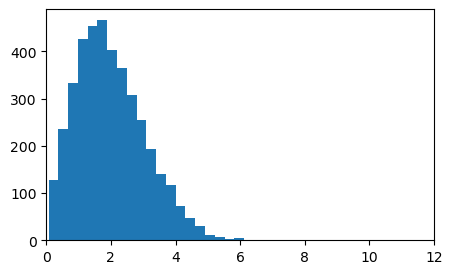

Mean of samples: 5.01519396597247
Standard deviation of samples: 2.6425110625390356


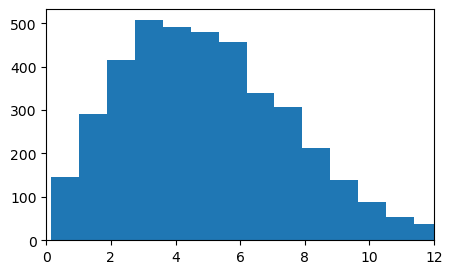

In [3]:
dc_mu, ac_mu = 2, 5

def sample_rayleigh(center, size=1):
    """
    Samples from a Rayleigh distribution with a controlled center
    """

    sigma= center / np.sqrt(np.pi / 2)
    samples = np.random.rayleigh(scale=sigma, size=size)
    return samples

# Example usage

samplesDC = sample_rayleigh(dc_mu, size=4000)
samplesAC = sample_rayleigh(ac_mu, size=4000)

plt.figure(figsize=(5,3))
plt.hist(samplesDC, bins = 20)
print("Mean of samples:", np.mean(samplesDC))
print("Standard deviation of samples:", np.std(samplesDC))
plt.xlim(0,12)
plt.show()

plt.figure(figsize=(5,3))
plt.hist(samplesAC, bins = 20)
print("Mean of samples:", np.mean(samplesAC))
print("Standard deviation of samples:", np.std(samplesAC))
plt.xlim(0,12)
plt.show()

## Getting net present value from line cash flow

In [7]:
def time_line(delay = 7, build_time = 3, cap_ex = .5, build_cost = .2, profit = .1,
              T = 20, rate = .07):
    '''
    we take out a loan at the beginning, start paying for construction after the delay
    and receive profits after the construction's build time
    '''
    seqs = {}
    seqs['cap_ex'] = np.zeros(T)
    seqs['cap_ex'][0] = -cap_ex

    seqs['build_cost'] = np.zeros(T)
    seqs['build_cost'][delay:delay+build_time] = -build_cost

    seqs['profit'] = np.zeros(T)
    seqs['profit'][delay+build_time:] =profit

    seqs['totals'] = seqs['cap_ex']+seqs['build_cost']+seqs['profit']

    seqs['discounts'] = (1+rate)**-np.arange(1,21)
    return seqs

    

In [41]:
seqs = time_line()
npv = seqs['totals'] * seqs['discounts']

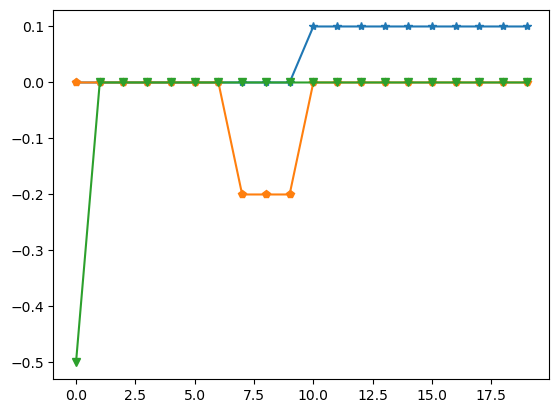

In [43]:
marks = '*pv'
for i,key in enumerate('profit build_cost cap_ex'.split(' ')):
    plt.plot(seqs[key], marker = marks[i], label ='key')
plt.show()

In [ ]:
from collections import defaultdict

data = defaultdict(list)
DC_costs = [1.5, 2.4, 3.3, 4.2]
AC_mus = np.arange(3,11,2)
AC_CAPEX = 1

for op_ex in [.07, .12, .2]:
    for delay_op_ex in [.1, .3, .6]:
        for DC_CAPEX in DC_costs:    
            for ac_mu in AC_mus:
                for i in range(60):
                    AC_delay = sample_rayleigh(ac_mu, size=1)
                    DC_delay = sample_rayleigh(3, size=1)
                    AC_NPV = loan_value( delay = np.ceil(AC_delay), cap_ex = AC_CAPEX, op_ex = op_ex,
                                       delay_op_ex = delay_op_ex, rate = .07,  T = 30)['NPV']
                    DC_NPV = loan_value( delay = np.ceil(DC_delay), cap_ex = DC_CAPEX, op_ex = op_ex,
                                       delay_op_ex = delay_op_ex, rate = .07,  T = 30)['NPV']
                    data['delay op ex'].append(delay_op_ex)
                    data['dc capex'].append(DC_CAPEX)
                    data['ac mean delay'].append(ac_mu)
                    data['dc advantage'].append(DC_NPV-AC_NPV)
                    data['op ex'].append(op_ex)




# Older stuff

In [13]:
def loan_value( delay = 3, cap_ex = 10, op_ex = 1, delay_op_ex = 0, 
               op_yield = 0, rate = .07,  T = 20, payments = 15):
    """ 
    given the delay, assume delay operational expenses and 
    spread out capital expense and returns only after the delay
    returns real time values of gains and losses for `time` years, 
    and the discounts needed for the NPV
    """

    #CAP EX
    cap_ex_seq = np.zeros(T)
    cap_ex_seq[:payments] = -cap_ex * rate*(1+rate)**payments / ( (1+rate)**payments-1)
    
    #DELAY EX
    delay_ex_seq = np.zeros(T)
    i = 0 
    while i < delay:
        delay_ex_seq[i] = - delay_op_ex
        i+=1

    # -OP EX + PROFIT
    op_ex_seq = np.zeros(T)
    rev_seq = np.zeros(T)

    while i < T:
        op_ex_seq[i] =  -op_ex
        rev_seq[i] = op_yield
        i+=1
    
    discounts = (1+rate)**(np.arange(T))
    NPV = np.sum(np.asarray([cap_ex_seq/discounts, delay_ex_seq/discounts,
                             op_ex_seq/discounts, rev_seq/discounts]))
    # `discounts` derived from Santarromana, Morgan delay paper
    return ({'cap_ex':cap_ex_seq/discounts, 'delay_ex':delay_ex_seq/discounts, 
            'op_ex':op_ex_seq/discounts, 'rev':rev_seq/discounts,
             'discounts': discounts, 'NPV': np.round(NPV, 5)})

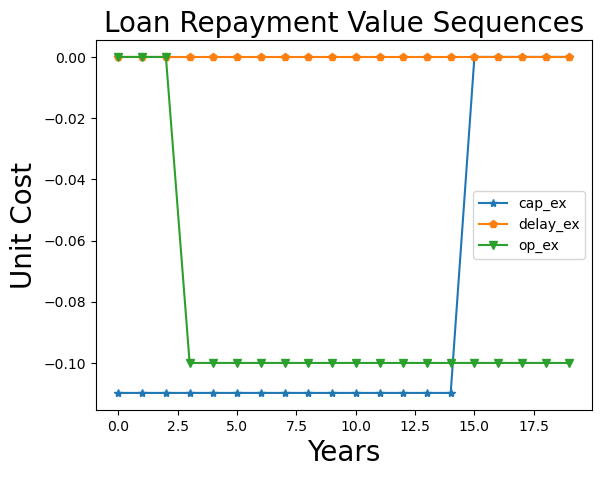

In [15]:
vals = loan_value()
markers = '*pv'
m=0
for i in vals:
    if i != 'NPV' and i != 'discounts' and i != 'rev':
        plt.plot(vals[i]*vals['discounts']/10, marker = markers[m],label = i)
        m+=1
plt.legend()
plt.title('Loan Repayment Value Sequences', fontsize=20)
plt.xlabel('Years', fontsize=20)
plt.ylabel('Unit Cost', fontsize=20)
plt.show()

## compared NPV values by DC cost and AC delay

In [73]:
from collections import defaultdict

data = defaultdict(list)
DC_costs = [1.5, 2.4, 3.3, 4.2]
AC_mus = np.arange(3,11,2)
AC_CAPEX = 1

for op_ex in [.07, .12, .2]:
    for delay_op_ex in [.1, .3, .6]:
        for DC_CAPEX in DC_costs:    
            for ac_mu in AC_mus:
                for i in range(60):
                    AC_delay = sample_rayleigh(ac_mu, size=1)
                    DC_delay = sample_rayleigh(3, size=1)
                    AC_NPV = loan_value( delay = np.ceil(AC_delay), cap_ex = AC_CAPEX, op_ex = op_ex,
                                       delay_op_ex = delay_op_ex, rate = .07,  T = 30)['NPV']
                    DC_NPV = loan_value( delay = np.ceil(DC_delay), cap_ex = DC_CAPEX, op_ex = op_ex,
                                       delay_op_ex = delay_op_ex, rate = .07,  T = 30)['NPV']
                    data['delay op ex'].append(delay_op_ex)
                    data['dc capex'].append(DC_CAPEX)
                    data['ac mean delay'].append(ac_mu)
                    data['dc advantage'].append(DC_NPV-AC_NPV)
                    data['op ex'].append(op_ex)




In [77]:


import sys

if not sys.warnoptions:
    import warnings
    warnings.simplefilter("ignore")

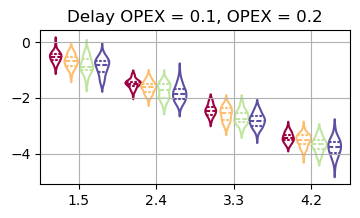

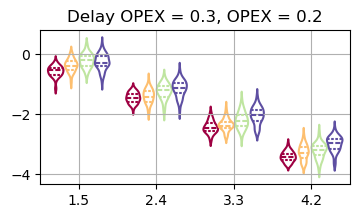

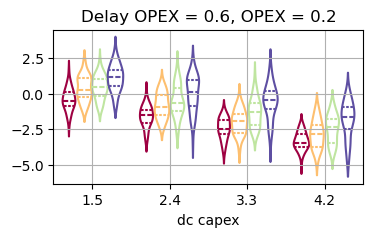

In [85]:
df = pd.DataFrame(data)
delays = [.1, .3, .6]
opexs = [.07, .12, .2]
# fig, ax = plt.subplots(3,3)
# fig.figsize=(2,2)
# for i in range(3):
op_ex = opexs[2]
for j in range(3):
    # plt.subplot(3,3,i*3+j+1)
    delay = delays[j]
    plt.figure(figsize=(4,2))
    
    graph = sb.violinplot(data= df[df['delay op ex']==delay][ df['op ex']==op_ex  ], x = 'dc capex', y= 'dc advantage',
                  hue = 'ac mean delay', palette=sb.color_palette('Spectral', as_cmap=True),
                 fill= False, inner='quartiles')
    graph.grid(True)
    if j >-1:
        graph.get_legend().remove()
    if j <2:
        graph.set(xlabel=None)
    graph.set(ylabel=None)
    plt.title(f'Delay OPEX = {delay}, OPEX = {op_ex}')
    plt.show()



# late capex

In [104]:
def late_value( delay = 3, cap_ex = 10, op_ex = 1, delay_op_ex = 2, 
               op_yield = 0, rate = .07,  T = 20, payments = 10):
    """ 
    given the delay, assume delay operational expenses and 
    spread out capital expense and returns only after the delay
    returns real time values of gains and losses for `time` years, 
    and the discounts needed for the NPV
    """

    #CAP EX
    cap_ex_seq = np.zeros(T)
    cap_ex_seq[int(delay)] = -cap_ex 
    
    #DELAY EX
    delay_ex_seq = np.zeros(T)
    i = 0 
    while i < delay:
        delay_ex_seq[i] = - delay_op_ex
        i+=1

    # -OP EX + PROFIT
    op_ex_seq = np.zeros(T)
    rev_seq = np.zeros(T)
    while i < T:
        op_ex_seq[i] =  -op_ex
        rev_seq[i] = op_yield
        i+=1
    
    discounts = (1+rate)**(np.arange(T))
    NPV = np.sum(np.asarray([cap_ex_seq/discounts, delay_ex_seq/discounts,
                             op_ex_seq/discounts, rev_seq/discounts]))
    # `discounts` derived from Santarromana, Morgan delay paper
    return ({'cap_ex':cap_ex_seq/discounts, 'delay_ex':delay_ex_seq/discounts, 
            'op_ex':op_ex_seq/discounts, 'rev':rev_seq/discounts,
             'discounts': discounts, 'NPV': np.round(NPV, 5)})

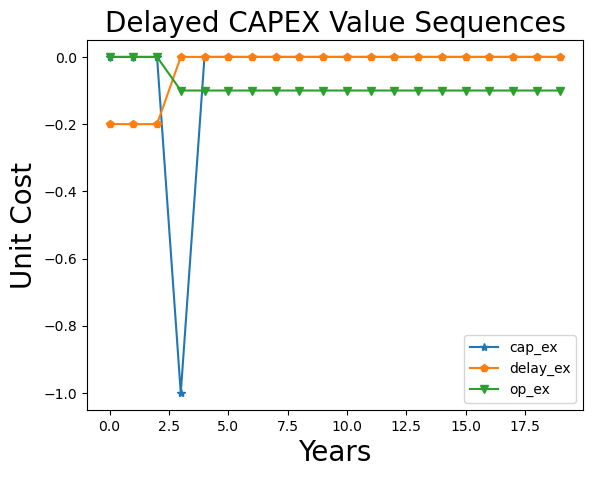

In [106]:
vals = late_value()
markers = '*pv'
m=0
for i in vals:
    if i != 'NPV' and i != 'discounts' and i != 'rev':
        plt.plot(vals[i]*vals['discounts']/10, marker = markers[m],label = i)
        m+=1
plt.legend()
plt.title('Delayed CAPEX Value Sequences', fontsize=20)
plt.xlabel('Years', fontsize=20)
plt.ylabel('Unit Cost', fontsize=20)
plt.show()

In [108]:
from collections import defaultdict

data = defaultdict(list)
DC_costs = [1.5, 2.4, 3.3, 4.2]
AC_mus = np.arange(3,11,2)
AC_CAPEX = 1

for op_ex in [.07, .12, .2]:
    for delay_op_ex in [.1, .3, .6]:
        for DC_CAPEX in DC_costs:    
            for ac_mu in AC_mus:
                for i in range(60):
                    AC_delay = sample_rayleigh(ac_mu, size=1)
                    DC_delay = sample_rayleigh(3, size=1)
                    AC_NPV = late_value( delay = np.ceil(AC_delay), cap_ex = AC_CAPEX, op_ex = op_ex,
                                       delay_op_ex = delay_op_ex, rate = .07,  T = 30)['NPV']
                    DC_NPV = late_value( delay = np.ceil(DC_delay), cap_ex = DC_CAPEX, op_ex = op_ex,
                                       delay_op_ex = delay_op_ex, rate = .07,  T = 30)['NPV']
                    data['delay op ex'].append(delay_op_ex)
                    data['dc capex'].append(DC_CAPEX)
                    data['ac mean delay'].append(ac_mu)
                    data['dc advantage'].append(DC_NPV-AC_NPV)
                    data['op ex'].append(op_ex)




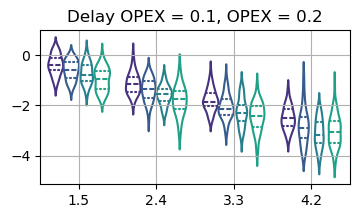

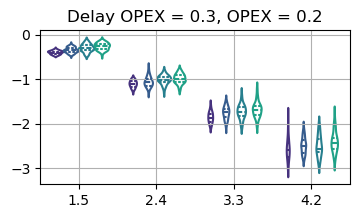

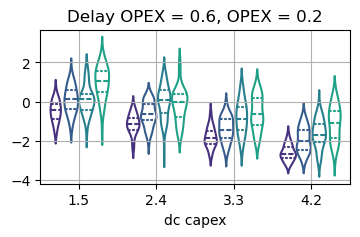

In [122]:
df = pd.DataFrame(data)
delays = [.1, .3, .6]
opexs = [.07, .12, .2]
# fig, ax = plt.subplots(3,3)
# fig.figsize=(2,2)
# for i in range(3):
op_ex = opexs[2]
for j in range(3):
    # plt.subplot(3,3,i*3+j+1)
    delay = delays[j]
    plt.figure(figsize=(4,2))
    
    graph = sb.violinplot(data= df[df['delay op ex']==delay][ df['op ex']==op_ex  ], x = 'dc capex', y= 'dc advantage',
                  hue = 'ac mean delay', palette=sb.color_palette('viridis', as_cmap=False),
                 fill= False, inner='quartiles')
    graph.grid(True)
    if j >0-1:
        graph.get_legend().remove()
    if j <2:
        graph.set(xlabel=None)
    graph.set(ylabel=None)
    plt.title(f'Delay OPEX = {delay}, OPEX = {op_ex}')
    plt.show()



# old stuff

In [35]:
val_comps[(1.0,ac_delay)]

NameError: name 'val_comps' is not defined

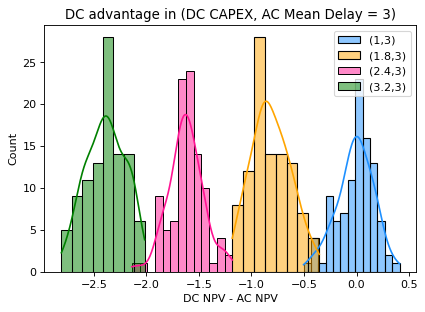

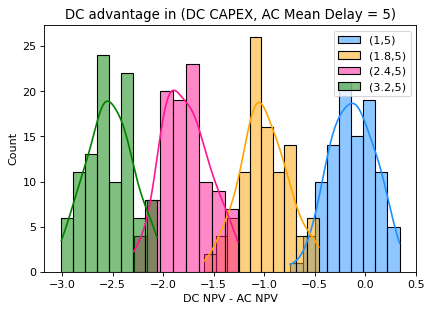

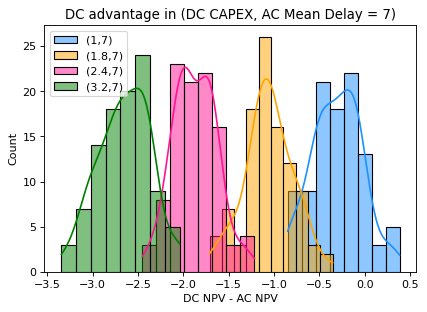

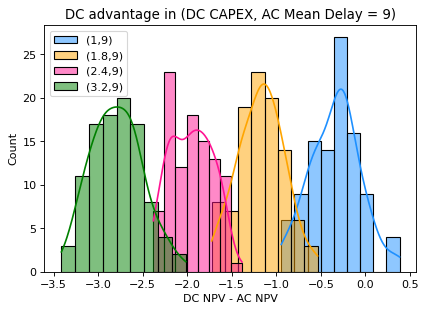

In [40]:
kwargs = dict(hist_kws={'alpha':.6}, kde_kws={'linewidth':2})

# sns.histplot(data=penguins, x="flipper_length_mm", kde=True)
for ac_delay in [3,5,7,9]:

    plt.figure(figsize=(6,4), dpi= 80)
    sb.histplot(val_comps[(1.0,ac_delay)], color="dodgerblue", label=f"(1,{ac_delay})", kde=True)
    sb.histplot(val_comps[(1.8,ac_delay)], color="orange", label=f"(1.8,{ac_delay})", kde=True)
    sb.histplot(val_comps[(2.6,ac_delay)], color="deeppink", label=f"(2.4,{ac_delay})", kde=True)
    sb.histplot(val_comps[(3.4,ac_delay)], color="green", label=f"(3.2,{ac_delay})", kde=True)
    plt.title(f'DC advantage in (DC CAPEX, AC Mean Delay = {ac_delay})')
    plt.xlabel('DC NPV - AC NPV')
    plt.legend()
    

# sb.displot(val_comps[1.8,3], color="orange", label="SUV", **kwargs)
# sb.displot(val_comps[2.2,7], color="deeppink", label="minivan", **kwargs)
# plt.xlim(50,75)


In [42]:
from collections import defaultdict

val_compsAC = defaultdict(list)
val_compsDC = defaultdict(list)
DC_costs = np.arange(10,38,4)/10
AC_mus = np.arange(3,10)
AC_CAPEX = 1


for DC_CAPEX in DC_costs:    
    for i in range(100):
        for ac_mu in AC_mus:
            AC_delay = sample_rayleigh(ac_mu, size=1)
            DC_delay = sample_rayleigh(3, size=1)
            AC_NPV = gen_value( delay = np.ceil(AC_delay), cap_ex = AC_CAPEX, op_ex = .2, delay_op_ex = .3, rate = .07,  T = 30)['NPV']
            DC_NPV = gen_value( delay = np.ceil(DC_delay), cap_ex = DC_CAPEX, op_ex = .2, delay_op_ex = .3, rate = .07,  T = 30)['NPV']
            val_compsDC[(DC_CAPEX, ac_mu)].append(DC_NPV)
            val_compsAC[(DC_CAPEX, ac_mu)].append(AC_NPV)
    

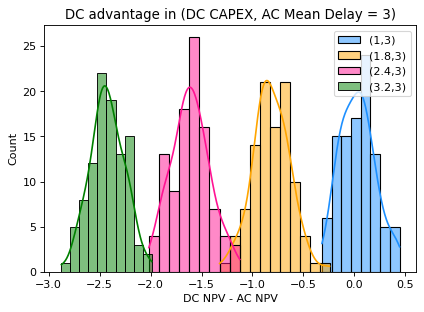

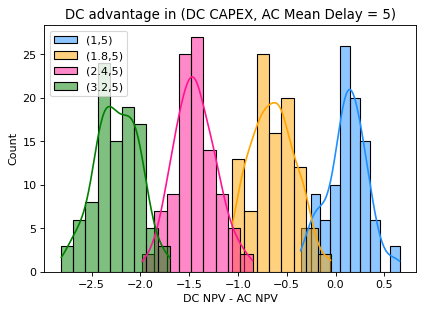

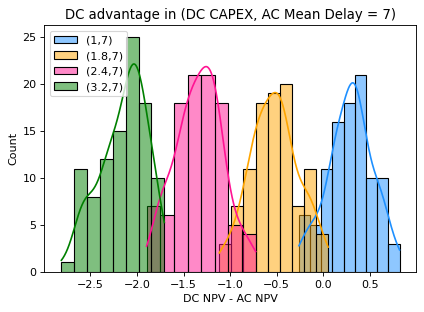

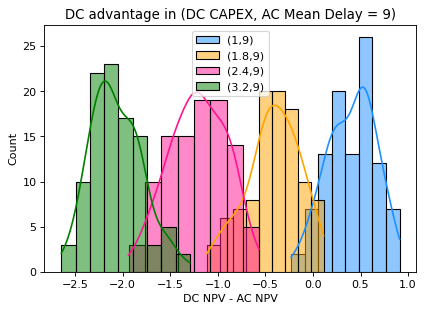

In [44]:
val_comps = {key: np.array(val_compsDC[key])-np.array(val_compsAC[key]) for key in val_compsDC.keys()}
kwargs = dict(hist_kws={'alpha':.6}, kde_kws={'linewidth':2})

# sns.histplot(data=penguins, x="flipper_length_mm", kde=True)
for ac_delay in [3,5,7,9]:

    plt.figure(figsize=(6,4), dpi= 80)
    sb.histplot(val_comps[(1.0,ac_delay)], color="dodgerblue", label=f"(1,{ac_delay})", kde=True)
    sb.histplot(val_comps[(1.8,ac_delay)], color="orange", label=f"(1.8,{ac_delay})", kde=True)
    sb.histplot(val_comps[(2.6,ac_delay)], color="deeppink", label=f"(2.4,{ac_delay})", kde=True)
    sb.histplot(val_comps[(3.4,ac_delay)], color="green", label=f"(3.2,{ac_delay})", kde=True)
    plt.title(f'DC advantage in (DC CAPEX, AC Mean Delay = {ac_delay})')
    plt.xlabel('DC NPV - AC NPV')
    plt.legend()
    

# sb.displot(val_comps[1.8,3], color="orange", label="SUV", **kwargs)
# sb.displot(val_comps[2.2,7], color="deeppink", label="minivan", **kwargs)
# plt.xlim(50,75)


In [46]:
from collections import defaultdict

val_compsAC = defaultdict(list)
val_compsDC = defaultdict(list)
DC_costs = np.arange(10,38,4)/10
AC_mus = np.arange(3,10)
AC_CAPEX = 1


for DC_CAPEX in DC_costs:    
    for i in range(100):
        for ac_mu in AC_mus:
            AC_delay = sample_rayleigh(ac_mu, size=1)
            DC_delay = sample_rayleigh(3, size=1)
            AC_NPV = gen_value( delay = np.ceil(AC_delay), cap_ex = AC_CAPEX, op_ex = .2, delay_op_ex = .6, rate = .07,  T = 30)['NPV']
            DC_NPV = gen_value( delay = np.ceil(DC_delay), cap_ex = DC_CAPEX, op_ex = .2, delay_op_ex = .6, rate = .07,  T = 30)['NPV']
            val_compsDC[(DC_CAPEX, ac_mu)].append(DC_NPV)
            val_compsAC[(DC_CAPEX, ac_mu)].append(AC_NPV)
    

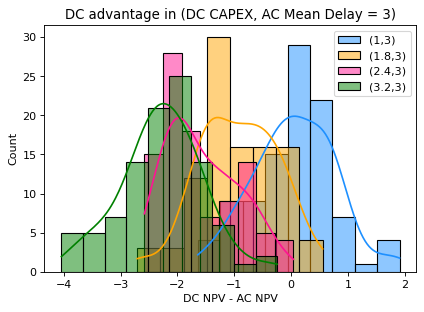

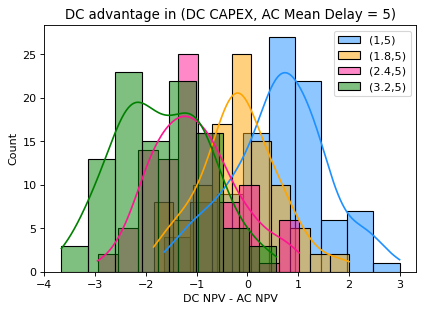

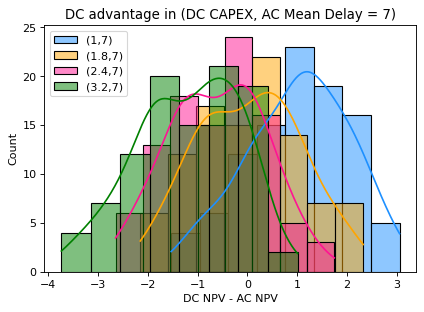

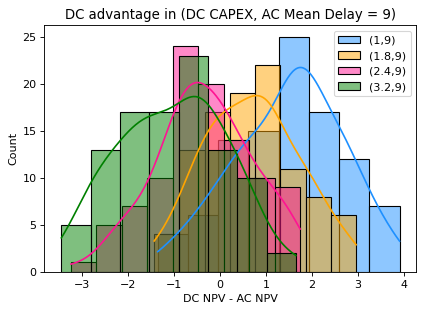

In [48]:
val_comps = {key: np.array(val_compsDC[key])-np.array(val_compsAC[key]) for key in val_compsDC.keys()}
kwargs = dict(hist_kws={'alpha':.6}, kde_kws={'linewidth':2})

# sns.histplot(data=penguins, x="flipper_length_mm", kde=True)
for ac_delay in [3,5,7,9]:

    plt.figure(figsize=(6,4), dpi= 80)
    sb.histplot(val_comps[(1.0,ac_delay)], color="dodgerblue", label=f"(1,{ac_delay})", kde=True)
    sb.histplot(val_comps[(1.8,ac_delay)], color="orange", label=f"(1.8,{ac_delay})", kde=True)
    sb.histplot(val_comps[(2.6,ac_delay)], color="deeppink", label=f"(2.4,{ac_delay})", kde=True)
    sb.histplot(val_comps[(3.4,ac_delay)], color="green", label=f"(3.2,{ac_delay})", kde=True)
    plt.title(f'DC advantage in (DC CAPEX, AC Mean Delay = {ac_delay})')
    plt.xlabel('DC NPV - AC NPV')
    plt.legend()
    

# sb.displot(val_comps[1.8,3], color="orange", label="SUV", **kwargs)
# sb.displot(val_comps[2.2,7], color="deeppink", label="minivan", **kwargs)
# plt.xlim(50,75)


## Compared NPV by DC cost, AC delay, and interest rate

In [175]:

val_compsAC = defaultdict(list)
val_compsDC = defaultdict(list)
DC_costs = np.arange(12,36)
AC_mus = np.arange(3,12)
disc_rates = np.arange(5, 12, 2)
AC_CAPEX = 10

for DC_CAPEX in DC_costs:    
    for i in range(20):
        for r in disc_rates:
            for ac_mu in AC_mus:
            ### ### AC ### ###
                AC_delay = sample_rayleigh(ac_mu, 2, size=1)
                DC_delay = sample_rayleigh(3, 1, size=1)
                AC_NPV = gen_value( delay = np.ceil(AC_delay), cap_ex = AC_CAPEX, op_ex = 1, delay_op_ex = 1,  op_yield = 3, rate = r/100,  T = 30)['NPV']
                DC_NPV = gen_value( delay = np.ceil(DC_delay), cap_ex = DC_CAPEX, op_ex = 1, delay_op_ex = 1,  op_yield = 3, rate = r/100,  T = 30)['NPV']
                val_compsDC[(DC_CAPEX, ac_mu,r)].append(DC_NPV)
                val_compsAC[(DC_CAPEX, ac_mu,r)].append(AC_NPV)
    

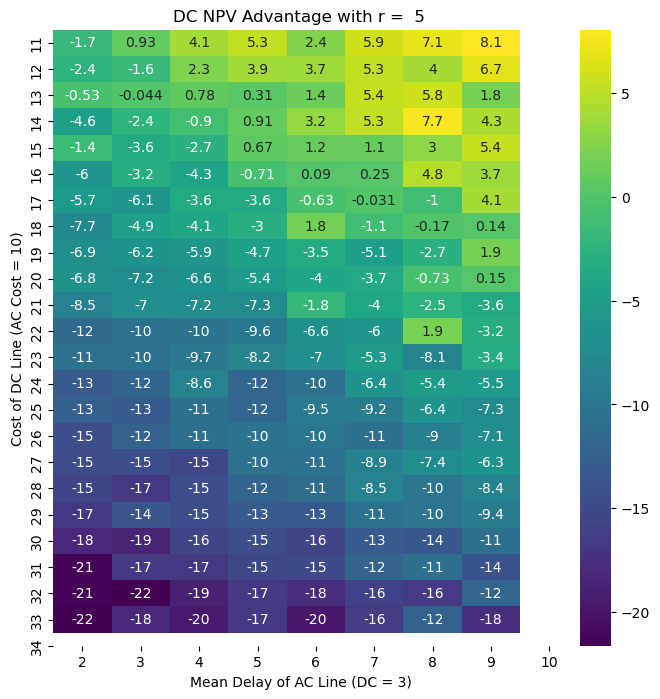

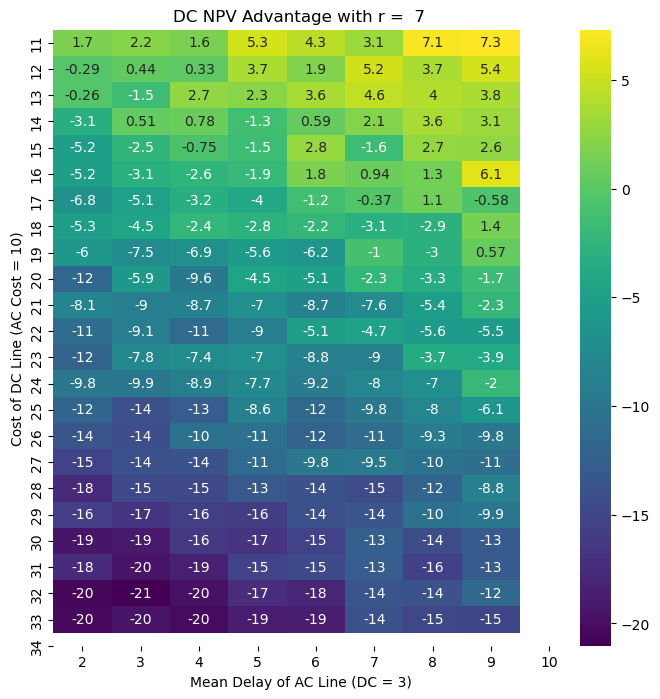

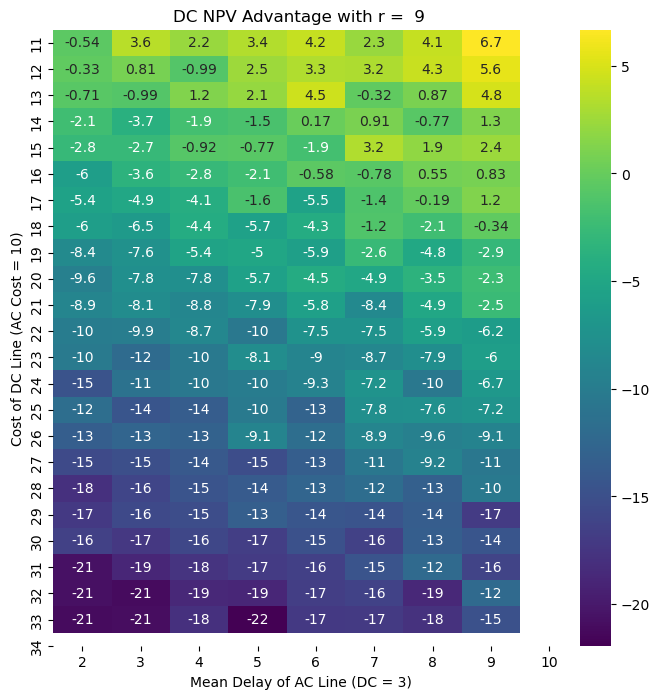

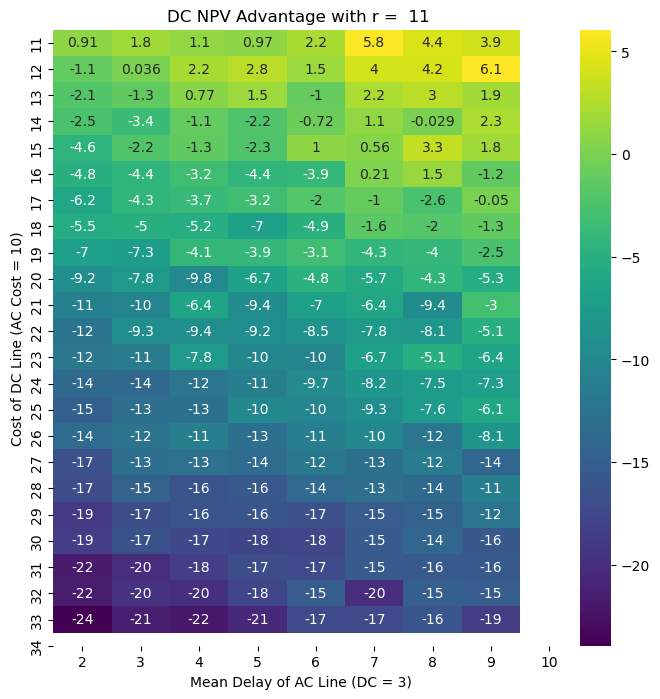

In [199]:

NPV_diffs = {}
for r in disc_rates:
    NPV_diffs[r] = np.zeros((DC_costs[-1], AC_mus[-1]))
for par in val_compsDC:
        NPV_diffs[par[2]][par[0]-1, par[1]-1] = np.mean(val_compsDC[par]) - np.mean(val_compsAC[par])

for r in disc_rates:
    plt.figure(figsize=(8,8))
    ax = sb.heatmap(NPV_diffs[r][DC_costs[0]:,AC_mus[0]:AC_mus[-1]+1], cmap = 'viridis',
               annot=True,  yticklabels = np.arange(11,len(disp_valsDiff)),
                  xticklabels = np.arange(2, 11))
# plt.title('DC NPV Advantage')
    plt.title(f'DC NPV Advantage with r =  {r} ')
    plt.ylabel('Cost of DC Line (AC Cost = 10)')
    plt.xlabel('Mean Delay of AC Line (DC = 3)')
    plt.show()

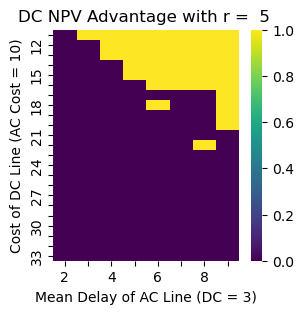

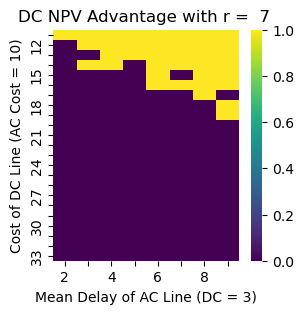

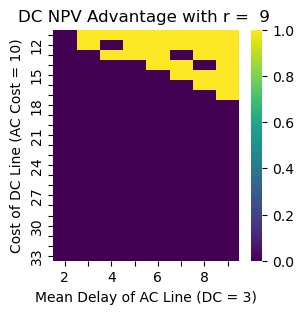

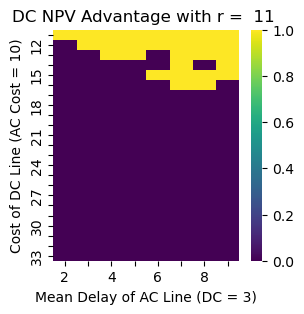

In [247]:
mayb = [2, None, 4,5,6,7,8,9]
xtik = [i if i%2==0 else None for i in range(2,10) ]
ytik = [i if i%3==0 else None for i in range(11,34) ]
for r in disc_rates:
    plt.figure(figsize=(3,3))
    ax = sb.heatmap(NPV_diffs[r][DC_costs[0]:,AC_mus[0]:AC_mus[-1]+1]>=0, cmap = 'viridis',  yticklabels = ytik,
          xticklabels = xtik)
    # plt.title('DC NPV Advantage')
    plt.title(f'DC NPV Advantage with r =  {r} ')
    plt.ylabel('Cost of DC Line (AC Cost = 10)')
    plt.xlabel('Mean Delay of AC Line (DC = 3)')
    plt.show()

## older stuff

In [23]:
delay = 3
cap = 10
T = 20
val_seq, discounts = gen_value(delay = delay, cap_ex = cap)
NPV = np.round(np.sum(val_seq/discounts), 2)
plt.figure(figsize = (6,3))
plt.plot(val_seq, label = 'real time value')
plt.plot(val_seq/discounts, label ='present time value')
plt.title('NPV = {} with delay = {} and cap ex = {}'.format(NPV, delay, cap))
plt.xlabel('t, Years')
plt.ylabel('$ Value at Time t')
plt.legend()
plt.show()

IndexError: index 10 is out of bounds for axis 0 with size 10

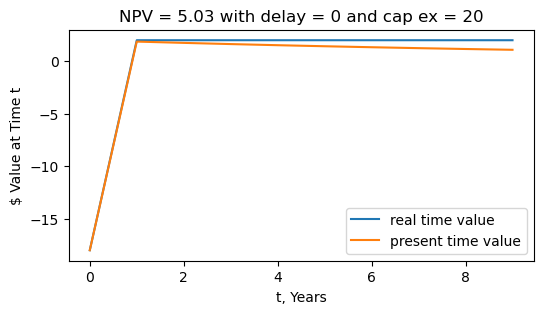

In [8]:
delay = 0
cap = 20
val_seq2, discounts2 = gen_value(delay = delay, cap_ex = cap)
NPV2 = np.round(np.sum(val_seq/discounts), 2)
plt.figure(figsize = (6,3))
plt.plot(val_seq2, label = 'real time value')
plt.plot(val_seq2/discounts2, label ='present time value')
plt.title('NPV = {} with delay = {} and cap ex = {}'.format(NPV2, delay, cap))
plt.xlabel('t, Years')
plt.ylabel('$ Value at Time t')
plt.legend()
plt.show()

## Probability distribution

In [10]:
delay_dist = np.random.rand(10)
delay_dist = delay_dist/np.sum(delay_dist)
print(np.round(delay_dist, 2))
# [0.13 0.14 0.03 0.02 0.11 0.07 0.04 0.16 0.17 0.13] 
# works fine with E[NPV] 4.8 and 3.5 and 10 and 20 capex

# [0.04 0.15 0.16 0.08 0.19 0.02 0.06 0.2  0.07 0.02] had 6.7 and 6.3 for capex 10, 20

[0.16 0.09 0.1  0.11 0.16 0.16 0.04 0.09 0.05 0.03]


In [11]:
def expect_npv(T, cap_ex, delay_dist, rate = 1.07):
    expect = 0
    for d in range(T):
        val_seq, discounts = gen_value(d, cap_ex = cap_ex, rate=rate)
        NPV = np.sum(val_seq/discounts)
        expect += NPV*delay_dist[d]
    return expect

In [12]:
expect_npv(T=10, cap_ex = 20, delay_dist = delay_dist)

-2.7168974237712415

In [13]:
expect_npv(T=10, cap_ex = 10, delay_dist = delay_dist)

-1.0729893292260895

In [15]:
def make_dist(arr):
    based = arr - np.min(arr)
    return np.round(based/np.sum(based),2)

In [17]:
peak_linear = -np.abs(np.arange(10) -3)
# method for linear prob dense func with peak at given year and slopes +/-1

In [18]:
make_dist(peak_linear)

array([0.09, 0.12, 0.15, 0.18, 0.15, 0.12, 0.09, 0.06, 0.03, 0.  ])

In [20]:
def norm_dist(mu, stdev, T=10):
   # mu, stdev = 3, 1
    cdf1 = scistat.norm.cdf(np.arange(T+1), mu, stdev)
    cdf2 = scistat.norm.cdf(np.arange(-1,T), mu, stdev)
    cdf2[0] = 0
    cdf = cdf1-cdf2
    return make_dist(cdf[:-1])
cdf = norm_dist(3,1)
# method for normal distribution prob dense func discretized
make_dist(cdf)

array([0.  , 0.02, 0.14, 0.34, 0.34, 0.14, 0.02, 0.  , 0.  , 0.  ])

Text(0.5, 1.0, 'Discretized Normal Distributions')

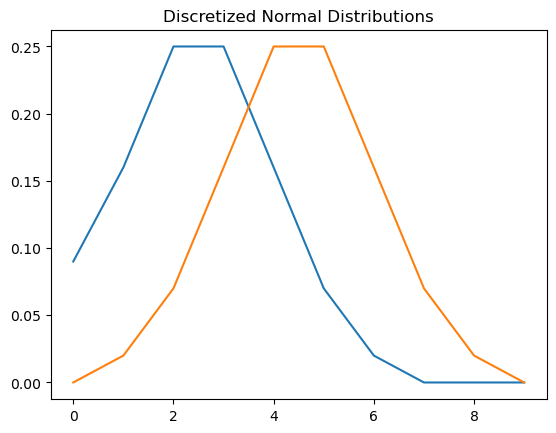

In [30]:
normdist2 = norm_dist(2,1.5)
normdist4 = norm_dist(4,1.5)
plt.plot(normdist2)
plt.plot(normdist4)
plt.title('Discretized Normal Distributions')

## exploring the mean, cap_ex space

In [45]:
e_npvs = {}
for rate in [.03, .05,  .07, .09]:
    e_npvs[rate] = np.zeros((6, 20))
    for mu in range(1,7):
        for cap in range(15,35):
            e_npvs[rate][mu-1, cap-15] = expect_npv(T=10, cap_ex = cap, 
                                                delay_dist = norm_dist(mu, 1.5),
                                               rate = rate)

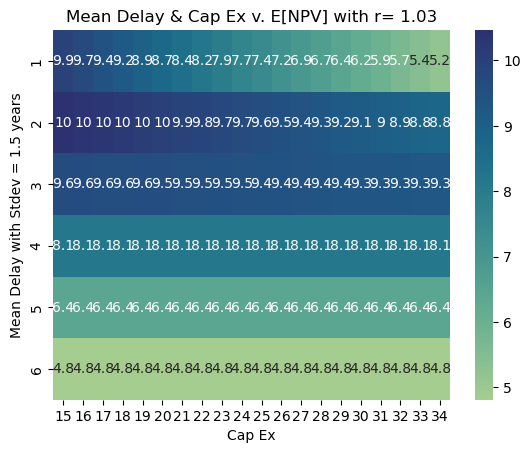

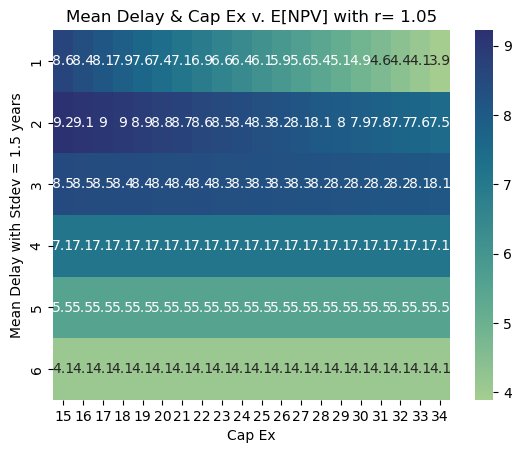

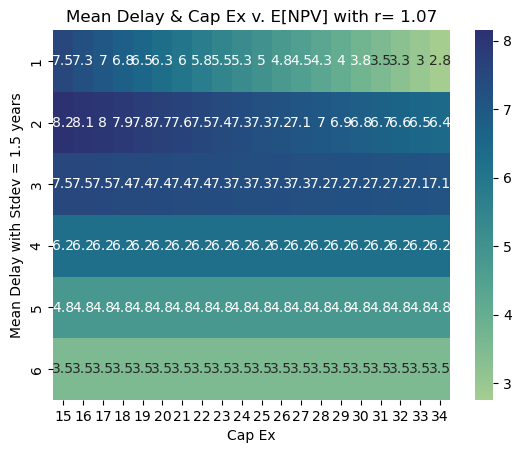

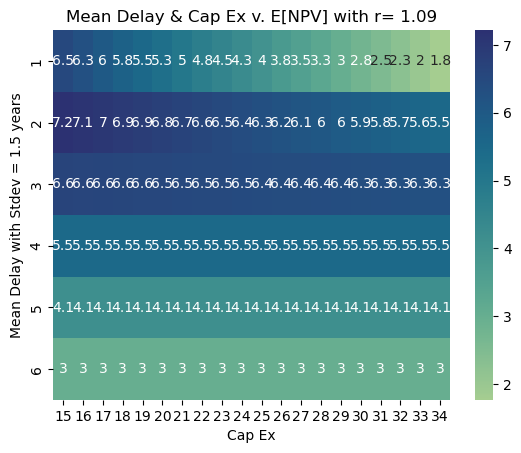

In [47]:
for rate in [.03, .05, .07, .09]:
    ax = sb.heatmap(e_npvs[rate], cmap = 'crest',
               annot=True, yticklabels = np.arange(1,7),
              xticklabels = np.arange(15, 35))
    plt.title('Mean Delay & Cap Ex v. E[NPV] with r= '+str(1+rate))
    plt.xlabel('Cap Ex')
    plt.ylabel('Mean Delay with Stdev = 1.5 years')
    plt.show()

## Loading ACEG Data on Interconnection wait
median lengths from request to agreement

In [160]:
textdata = """
California/CAISO 31 31 29 2.13 85% B \n
Mid-Atlantic/PJM 36 44 46 1.88 75% C \n
Midwest/MISO 30 34 39 1.88 75% C \n
NewEngland/ISO-NE 0 0 0 0.00 0% F \n
NewYork/NYISO 55 31 37 1.88 75% C \n
Northwest/NorthernGrid 33 32 32 2.13 85% B \n
Plains/SPP 40 42 51 1.63 65% D \n
Southeast/SERTP,SCRTP,FRCC 21 15 18 2.50 100% A \n
Southwest/WestConnect 33 32 32 2.13 85% B \n
Texas/ERCOT 20 21 18 2.50 100% A \n
""".split('\n')

predata = np.array([pre.split(' ') + [len(pre.split(' '))] for pre in textdata if len(pre)>1])

connect_wait  = pd.DataFrame(predata[:,1:4].astype(int),
                            columns = [ 'IW 2019', 'IW 2020', 'IW 2021'])
connect_wait['Region'] = predata[:,0]


"""
# DATA from 
Zimmerman, Zach, et al. Transmission Planning And Development Regional Report Card.
Americans for a Clean Energy Grid, June 2023, 
https://www.cleanenergygrid.org/wp-content/uploads/2023/06/ACEG_Transmission_Planning_and_Development_Report_Card.pdf.
pg 66 table 20  Grade for median duration from interconnection request to interconnection
agreement in Month
"""

'\n# DATA from \nZimmerman, Zach, et al. Transmission Planning And Development Regional Report Card.\nAmericans for a Clean Energy Grid, June 2023, \nhttps://www.cleanenergygrid.org/wp-content/uploads/2023/06/ACEG_Transmission_Planning_and_Development_Report_Card.pdf.\npg 66 table 20\n'

In [156]:
connect_wait

,IW 2019,IW 2020,IW 2021,Region
0,31,31,29,California/CAISO
1,36,44,46,Mid-Atlantic/PJM
2,30,34,39,Midwest/MISO
3,0,0,0,NewEngland/ISO-NE
4,55,31,37,NewYork/NYISO
5,33,32,32,Northwest/NorthernGrid
6,40,42,51,Plains/SPP
7,21,15,18,"Southeast/SERTP,SCRTP,FRCC"
8,33,32,32,Southwest/WestConnect
9,20,21,18,Texas/ERCOT


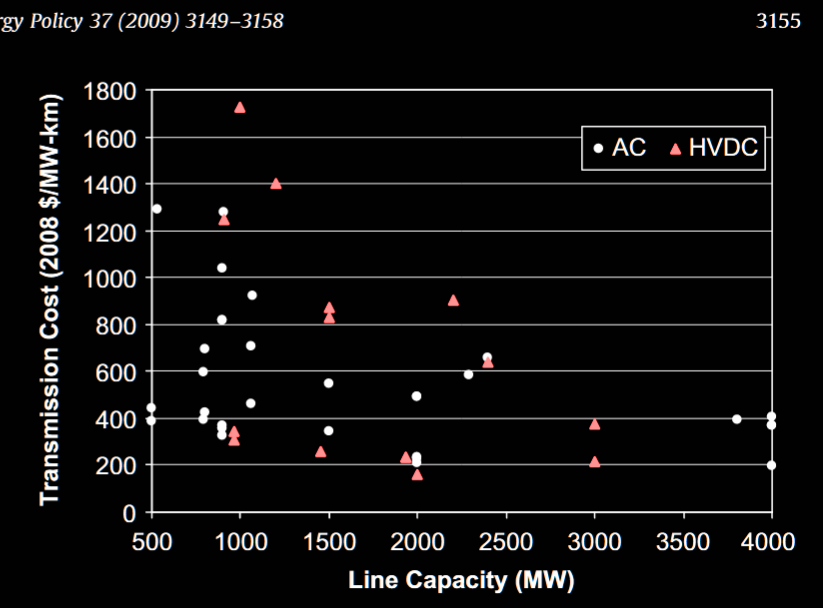